In [779]:
import zipfile
import os
import base64
import io
import time
import requests
import chardet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display
from PIL import Image as im
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc, r2_score, mean_squared_error)

## Credits

**Dataset:** [Telecom Churn Dataset](https://www.kaggle.com/datasets/suraj520/telecom-churn-dataset) by [Suraj](https://www.kaggle.com/suraj520) on Kaggle

**License:** [CC0: Public Domain](https://creativecommons.org/publicdomain/zero/1.0/)

---

## Problem Statement

Customer churn is a critical challenge in the Indian telecom industry. When customers switch providers, companies lose recurring revenue and must spend significantly more to acquire new customers than to retain existing ones.

This dataset contains **243,553 rows** of customer data from four major Indian telecom partners — **Airtel, Reliance Jio, Vodafone, and BSNL**. Each record includes demographic, geographic, and usage attributes along with a binary churn label.

**Objective:** Analyze customer behavior and build predictive models to identify customers likely to churn, enabling proactive retention strategies.

### Features

| Feature | Description |
|---|---|
| `customer_id` | Unique identifier for each customer |
| `telecom_partner` | Telecom provider (Airtel, Jio, Vodafone, BSNL) |
| `gender` | Gender of the customer |
| `age` | Age of the customer |
| `state` | Indian state of the customer |
| `city` | City of the customer |
| `pincode` | Pincode of the customer's location |
| `date_of_registration` | Date the customer registered with the telecom partner |
| `num_dependents` | Number of dependents (e.g. children) |
| `estimated_salary` | Customer's estimated salary |
| `calls_made` | Number of calls made |
| `sms_sent` | Number of SMS messages sent |
| `data_used` | Amount of data used |
| `churn` | Binary target — 1 = churned, 0 = not churned |

### Potential Use Cases

- Customer churn prediction
- Customer segmentation
- Customer lifetime value estimation
- Exploratory data analysis of the Indian telecom industry

In [714]:
def mm(graph, retries=5):
    graphbytes = graph.encode("utf8")
    base64_bytes = base64.urlsafe_b64encode(graphbytes)
    base64_string = base64_bytes.decode("ascii")
    url = 'https://mermaid.ink/img/' + base64_string

    for attempt in range(retries):
        try:
            response = requests.get(url, timeout=10)
            response.raise_for_status()
            img = im.open(io.BytesIO(response.content))
            plt.figure(figsize=(14, max(8, len(graph.splitlines()) * 0.4)))
            plt.imshow(img)
            plt.axis('off')
            plt.show()
            return
        except Exception as e:
            if attempt < retries - 1:
                wait = 2 ** attempt
                print(f"Attempt {attempt + 1} failed: {e}. Retrying in {wait}s...")
                time.sleep(wait)
            else:
                print(f"All {retries} attempts failed: {e}")

In [715]:
def extract_zip(zip_filename, output_dir):
    """
    Extract a ZIP file to a specified directory.
    
    Parameters:
    zip_filename (str): Path to the ZIP file.
    output_dir (str): Directory where to extract the contents.
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extractall(output_dir)
    
    print(f"Extracted {zip_filename} to {output_dir}")

In [716]:
pwd = os.getcwd()
print("Current working directory:", pwd)

input_file = os.path.join(pwd, 'input', 'archive.zip')
output_dir = os.path.join(pwd)

extract_zip(input_file, output_dir)

Current working directory: /home/sandeep/workspace/learn-ml/ml-201/telecom_churn_dataset
Extracted /home/sandeep/workspace/learn-ml/ml-201/telecom_churn_dataset/input/archive.zip to /home/sandeep/workspace/learn-ml/ml-201/telecom_churn_dataset


In [717]:
def display_info(df):
    """
    Display basic information about the DataFrame.
    """
    print(f"Shape: {df.shape}")
    print(f"Number of rows: {df.shape[0]}")
    print(f"Number of columns: {df.shape[1]}")

    print()
    print("--- Data Types ---")
    print(df.dtypes)

    print()
    print("--- Memory Usage ---")
    print(df.memory_usage(deep=True))

    print()
    print("--- Unique Values ---")
    print(df.nunique())

    print()
    print("--- Numeric Summary ---")
    print(df.describe())

    print()
    print("--- Categorical Summary ---")
    cat_cols = df.select_dtypes(include='object').columns
    if len(cat_cols) > 0:
        print(df[cat_cols].describe())
    else:
        print("No categorical columns")

In [718]:
def display_column_datatype(df, column_names):
    """
    Display the data type of specified columns.
    """
    if not column_names:
        print("No columns provided. Nothing to do.")
        return

    print("--- Column Data Types ---")
    for col in column_names:
        if col not in df.columns:
            print(f"  {col}: not found")
        else:
            print(f"  {col}: {df[col].dtype}")

In [719]:
def mindmap_columns(df):
    """
    Draw a mindmap of DataFrame columns using Mermaid.js, grouped by data type.
    """
    # Group columns by dtype
    dtype_groups = {}
    for col in df.columns:
        dtype_str = str(df[col].dtype)
        if dtype_str not in dtype_groups:
            dtype_groups[dtype_str] = []
        dtype_groups[dtype_str].append(col)

    # Build Mermaid mindmap syntax
    lines = ["mindmap", "  root((DataFrame))"]
    for dtype_str, cols in dtype_groups.items():
        lines.append(f"    {dtype_str}")
        for col in cols:
            lines.append(f"      {col}")

    graph = "\n".join(lines)
    mm(graph)

In [720]:
def missing_summary(df):
    """
    Display missing values count and percentage per column.
    """
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
    missing_with_values = missing_df[missing_df['Missing'] > 0]

    print("--- Missing Values ---")
    if len(missing_with_values) > 0:
        print(missing_with_values)
    else:
        print("No missing values")
    print()
    print(f"Total missing: {missing.sum()}")

In [721]:
def duplicate_summary(df):
    """
    Display duplicate row count and show duplicates if any.
    """
    dup_count = df.duplicated().sum()
    print("--- Duplicates ---")
    print(f"Duplicate rows: {dup_count}")
    if dup_count > 0:
        print()
        print("Duplicate rows:")
        print(df[df.duplicated(keep=False)])

In [722]:
def encoding_summary(file_path):
    """
    Detect and display the character encoding of a file,
    and check string columns for non-ASCII characters.
    """
    with open(file_path, 'rb') as f:
        raw = f.read()

    result = chardet.detect(raw)
    print("--- File Encoding ---")
    print(f"  Encoding:   {result['encoding']}")
    print(f"  Confidence: {result['confidence']:.2%}")
    print(f"  Language:   {result.get('language', 'N/A')}")
    print()

    df = pd.read_csv(file_path)
    str_cols = df.select_dtypes(include='object').columns

    print("--- Non-ASCII Characters in String Columns ---")
    found = False
    for col in str_cols:
        non_ascii = df[col].dropna().apply(lambda x: any(ord(c) > 127 for c in str(x)))
        count = non_ascii.sum()
        if count > 0:
            found = True
            print(f"  {col}: {count} rows with non-ASCII characters")
            samples = df[col][non_ascii].head(3).tolist()
            for s in samples:
                print(f"    Example: {s}")
    if not found:
        print("  All string columns contain only ASCII characters")

In [723]:
def display_rows(df, n=5):
    """
    Display the first and last n rows of the DataFrame as formatted tables.
    If n != len(df), display both first and last n rows.
    If n == len(df), display all rows in one table.
    """
    def print_table(title, data):
        table = data.to_string()
        lines = table.split('\n')
        width = max(len(line) for line in lines)
        sep = '-' * width
        print(title)
        print(sep)
        print(lines[0])
        print(sep)
        for line in lines[1:]:
            print(line)
        print(sep)

    if n == len(df):
        # Display all rows
        print_table(f"--- All {n} Rows ---", df)
    else:
        # Display both first and last n rows
        print_table(f"--- First {n} Rows ---", df.head(n))
        print()
        print_table(f"--- Last {n} Rows ---", df.tail(n))

In [724]:
def datetime_formatting(df, column_names):
    """
    Parse specified columns as datetime and display summary info.
    Returns the modified DataFrame.
    """
    if not column_names:
        print("No columns provided. Nothing to do.")
        return df

    df = df.copy()

    for col in column_names:
        if col not in df.columns:
            print(f"Column '{col}' not found in DataFrame. Skipping.")
            continue

        print(f"--- {col} ---")
        print(f"  Before: {df[col].dtype}")

        df[col] = pd.to_datetime(df[col], errors='coerce')

        print(f"  After:  {df[col].dtype}")
        parsed = df[col].dropna()
        if len(parsed) > 0:
            print(f"  Min:    {parsed.min()}")
            print(f"  Max:    {parsed.max()}")
            print(f"  Range:  {parsed.max() - parsed.min()}")
        failed = df[col].isna().sum() - df[col].isna().sum()
        original_nulls = pd.to_datetime(df[col], errors='coerce').isna().sum()
        print(f"  Parsed: {len(parsed)} / {len(df)}")
        print()

    display_rows(df)
    return df

In [725]:
def normalize_case(df, column_names=None):
    """
    Convert string columns to uppercase.
    Returns the modified DataFrame.
    """
    df = df.copy()

    if column_names is None:
        column_names = df.select_dtypes(include='object').columns.tolist()

    if not column_names:
        print("No string columns to normalize.")
        return df

    print("--- Normalize Case (Uppercase) ---")
    for col in column_names:
        if col not in df.columns:
            print(f"  Column '{col}' not found. Skipping.")
            continue

        df[col] = df[col].str.upper()
        print(f"  {col}: converted to uppercase")

    print()
    display_rows(df)
    return df

In [726]:
def drop_columns(df, column_names):
    """
    Drop specified columns from the DataFrame.
    Returns the modified DataFrame.
    """
    if not column_names:
        print("No columns provided. Nothing to do.")
        return df

    df = df.copy()

    print("--- Drop Columns ---")
    for col in column_names:
        if col not in df.columns:
            print(f"  {col}: not found. Skipping.")
        else:
            df = df.drop(columns=[col])
            print(f"  {col}: dropped")

    print()
    print(f"Remaining columns: {len(df.columns)}")
    return df

In [727]:
def whitespace_trimming(df, column_names=None):
    """
    Strip leading and trailing whitespace from string columns.
    Returns the modified DataFrame.
    """
    df = df.copy()

    if column_names is None:
        column_names = df.select_dtypes(include='object').columns.tolist()

    if not column_names:
        print("No string columns to trim.")
        return df

    print("--- Whitespace Trimming ---")
    for col in column_names:
        if col not in df.columns:
            print(f"  Column '{col}' not found. Skipping.")
            continue

        before = df[col].copy()
        df[col] = df[col].str.strip()
        trimmed = (before != df[col]).sum()
        print(f"  {col}: {trimmed} values trimmed")

    print()
    display_rows(df)
    return df

In [728]:
def column_classification(df, column_name):
    """
    Classify a column and return unique items.
    Replaces column values with their index in the unique items list.
    Returns a tuple of (updated df, list of unique items).
    """
    if column_name not in df.columns:
        print(f"Column '{column_name}' not found.")
        return df, []

    df = df.copy()
    unique_items = df[column_name].dropna().unique().tolist()
    value_to_index = {v: i for i, v in enumerate(unique_items)}

    print(f"--- {column_name} ---")
    print(f"  Dtype:   {df[column_name].dtype}")
    print(f"  Unique:  {len(unique_items)}")
    print(f"  Mapping:")
    for v, i in value_to_index.items():
        print(f"    {v} -> {i}")

    df[column_name] = df[column_name].map(value_to_index)

    return df, unique_items

In [729]:
def column_uniques(df, column_name, verbose=True):
    """
    Get unique items from a column.
    Returns a list of unique values (excluding NaN).
    """
    if column_name not in df.columns:
        if verbose:
            print(f"Column '{column_name}' not found.")
        return []
    
    unique_items = df[column_name].dropna().unique().tolist()
    
    if verbose:
        print(f"--- {column_name} ---")
        print(f"  Dtype:   {df[column_name].dtype}")
        print(f"  Unique:  {len(unique_items)}")
        print(f"  Items:")
        for i, item in enumerate(unique_items):
            print(f"    {i}: {item}")
    
    return unique_items

In [730]:
def datetime_age_classification(df, column_name, target_column):
    """
    Calculate age in days from a datetime column.
    Adds a new target_column with the computed age values.
    Returns the modified DataFrame.
    """
    if column_name not in df.columns:
        print(f"Column '{column_name}' not found.")
        return df

    if target_column in df.columns:
        print(f"Column '{target_column}' already exists.")
        return df

    if not pd.api.types.is_datetime64_any_dtype(df[column_name]):
        print(f"Column '{column_name}' is not datetime dtype.")
        return df

    df = df.copy()
    now = pd.Timestamp.now()
    df[target_column] = (now - df[column_name]).dt.days

    print(f"--- {target_column} ---")
    print(f"  Source:  {column_name}")
    print(f"  Now:     {now}")
    print(f"  Min:     {df[target_column].min()} days")
    print(f"  Max:     {df[target_column].max()} days")
    print(f"  Mean:    {df[target_column].mean():.2f} days")

    return df

In [731]:
def range_summary(df):
    """
    Print min, max, mean, std deviation, and other stats for all numeric columns.
    """
    numeric_cols = df.select_dtypes(include='number').columns

    if len(numeric_cols) == 0:
        print("No numeric columns found.")
        return

    rows = []
    for col in numeric_cols:
        mean = df[col].mean()
        std = df[col].std()

        rows.append({
            'Column':   col,
            'Count':    df[col].count(),
            'Nulls':    df[col].isna().sum(),
            'Min':      round(df[col].min(), 4),
            'Max':      round(df[col].max(), 4),
            'Range':    round(df[col].max() - df[col].min(), 4),
            'Mean':     round(mean, 4),
            'Median':   round(df[col].median(), 4),
            'Mode':     round(df[col].mode()[0], 4),
            'Std':      round(std, 4),
            'Variance': round(df[col].var(), 4),
        })

    stats_df = pd.DataFrame(rows).set_index('Column')
    table = stats_df.to_string()
    lines = table.split('\n')
    width = max(len(line) for line in lines)
    sep = '-' * width

    print("--- Numeric Column Ranges ---")
    print(sep)
    print(lines[0])
    print(sep)
    for line in lines[1:]:
        print(line)
    print(sep)

In [732]:
def plot_spread(values, column_name):
    """
    Plot histogram and boxplot side by side for a given series.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(values, bins=30, color='salmon', edgecolor='black')
    axes[0].set_title(f'{column_name} — Histogram')
    axes[0].set_xlabel(column_name)
    axes[0].set_ylabel('Frequency')

    axes[1].boxplot(values, vert=True)
    axes[1].set_title(f'{column_name} — Boxplot')
    axes[1].set_ylabel(column_name)

    plt.tight_layout()
    plt.show()

In [733]:
def extract_column(df, column_name):
    """
    Extract a column's non-null values as a Series.
    """
    if column_name not in df.columns:
        print(f"Column '{column_name}' not found.")
        return pd.Series(dtype='float64')

    return df[column_name].dropna()

In [734]:
def count_negatives(df, column_name):
    """
    Count negative values in a column and display their spread.
    Returns a tuple of (negative count, total count, probability).
    """
    if column_name not in df.columns:
        print(f"Column '{column_name}' not found.")
        return 0, 0, 0.0

    total = df[column_name].count()
    neg_mask = df[column_name] < 0
    negatives = neg_mask.sum()
    probability = negatives / total if total > 0 else 0.0

    print(f"--- {column_name} ---")
    print(f"  Negatives:   {negatives}")
    print(f"  Total:       {total}")
    print(f"  Probability: {probability:.4f}")

    if negatives > 0:
        neg_values = df.loc[neg_mask, column_name]
        print(f"  Min:         {neg_values.min():.4f}")
        print(f"  Max:         {neg_values.max():.4f}")
        print(f"  Mean:        {neg_values.mean():.4f}")
        print(f"  Median:      {neg_values.median():.4f}")
        print(f"  Std:         {neg_values.std():.4f}")
        plot_spread(neg_values, f'{column_name} (negatives)')

    return negatives, total, probability

In [735]:
def invert_negatives(df, column_names):
    """
    Invert negative values to positive by multiplying them by -1.
    Returns the modified DataFrame.
    """
    if not column_names:
        print("No columns provided. Nothing to do.")
        return df

    df = df.copy()

    print("--- Invert Negatives ---")
    for col in column_names:
        if col not in df.columns:
            print(f"  {col}: not found. Skipping.")
            continue

        neg_mask = df[col] < 0
        count = neg_mask.sum()
        df.loc[neg_mask, col] = df.loc[neg_mask, col] * -1
        print(f"  {col}: {count} negatives inverted")

    print()
    display_rows(df)
    return df

In [736]:
def count_classifications(df, column_name, classifications, verbose=True):
    """
    Count occurrences of each classification in a label-encoded column.
    Returns a dict mapping classification name to count.
    """
    if column_name not in df.columns:
        if verbose:
            print(f"Column '{column_name}' not found.")
        return {}

    counts = df[column_name].value_counts().sort_index()
    result = {}

    if verbose:
        print(f"--- {column_name} ---")
    for idx, name in enumerate(classifications):
        count = counts.get(idx, 0)
        result[name] = count
        if verbose:
            print(f"  {name}: {count}")

    if verbose:
        print(f"  Total: {counts.sum()}")
    return result

In [737]:
def piechart(counts, title):
    """
    Plot a pie chart from a counts dict {label: count}.
    """
    labels = list(counts.keys())
    values = list(counts.values())

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

In [738]:
def piechart_comparison(counts_churned, counts_not_churned, title):
    """
    Plot two pie charts side by side comparing churned vs not churned.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    labels_churned = list(counts_churned.keys())
    values_churned = list(counts_churned.values())
    
    labels_not_churned = list(counts_not_churned.keys())
    values_not_churned = list(counts_not_churned.values())
    
    axes[0].pie(values_churned, labels=labels_churned, autopct='%1.1f%%', startangle=90)
    axes[0].set_title(f'Churned - {title}')
    
    axes[1].pie(values_not_churned, labels=labels_not_churned, autopct='%1.1f%%', startangle=90)
    axes[1].set_title(f'Not Churned - {title}')
    
    plt.tight_layout()
    plt.show()

In [739]:
def stacked_barplot(df, category_col, value_cols, title,
                    xlabel=None, ylabel="Percentage (%)",
                    colors=None, normalize=True):
    """
    Plot a 100% stacked bar chart from a DataFrame.

    Parameters:
    df            : DataFrame with the data to plot.
    category_col  : Column name for the x-axis categories.
    value_cols    : List of column names to stack (e.g. ['Not Churned', 'Churned']).
    title         : Chart title.
    xlabel        : X-axis label (defaults to category_col).
    ylabel        : Y-axis label.
    colors        : List of colors for each segment (defaults to seaborn palette).
    normalize     : If True, normalize each bar to 100%.
    """
    plot_data = df[[category_col] + value_cols].copy()
    labels = plot_data[category_col].tolist()

    if normalize:
        totals = plot_data[value_cols].sum(axis=1)
        for col in value_cols:
            plot_data[col] = plot_data[col] / totals * 100

    if colors is None:
        colors = sns.color_palette("muted", len(value_cols))

    x = range(len(labels))
    fig, ax = plt.subplots(figsize=(max(8, len(labels) * 0.7), 5))

    bottom = [0] * len(labels)
    for i, col in enumerate(value_cols):
        values = plot_data[col].tolist()
        ax.bar(x, values, bottom=bottom, label=col, color=colors[i])
        bottom = [b + v for b, v in zip(bottom, values)]

    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_xlabel(xlabel or category_col)
    ax.set_ylabel(ylabel)
    if normalize:
        ax.set_ylim(0, 100)
    ax.set_title(title)
    ax.legend()

    plt.tight_layout()
    plt.show()


def stacked_bar_comparison(counts_churned, counts_not_churned, title):
    """
    Plot a 100% stacked bar chart comparing churn rate per category.
    Wrapper around stacked_barplot for dict-based inputs.
    """
    labels = list(counts_churned.keys())
    churned = [counts_churned.get(l, 0) for l in labels]
    not_churned = [counts_not_churned.get(l, 0) for l in labels]

    plot_df = pd.DataFrame({
        'Category': labels,
        'Not Churned': not_churned,
        'Churned': churned,
    })

    stacked_barplot(
        plot_df,
        category_col='Category',
        value_cols=['Not Churned', 'Churned'],
        title=f'{title} — Churn Rate by Category (100% Stacked)',
        colors=['steelblue', 'salmon'],
    )

In [740]:
def part_whole_barplot(df, category_col, total_col, subset_col, title,
                       total_label="Total", subset_label="Subset",
                       xlabel="Count", ylabel=None):
    """
    Plot a horizontal part-whole bar chart using Seaborn.
    A pastel bar shows the total and a muted bar overlays the subset.
    X-axis is displayed as percentage of the grand total.

    Parameters:
    df            : DataFrame with the data to plot.
    category_col  : Column name for the y-axis categories.
    total_col     : Column name for the full-length bars.
    subset_col    : Column name for the overlaid subset bars.
    title         : Chart title.
    total_label   : Legend label for the total bars.
    subset_label  : Legend label for the subset bars.
    xlabel        : X-axis label.
    ylabel        : Y-axis label (defaults to category_col).
    """
    plot_data = df[[category_col, total_col, subset_col]].copy()
    grand_total = plot_data[total_col].sum()
    plot_data[total_col] = plot_data[total_col] / grand_total * 100
    plot_data[subset_col] = plot_data[subset_col] / grand_total * 100

    f, ax = plt.subplots(figsize=(10, max(4, len(plot_data) * 1.2)))

    sns.set_color_codes("pastel")
    sns.barplot(x=total_col, y=category_col, data=plot_data,
                label=total_label, color="b", ax=ax)

    sns.set_color_codes("muted")
    sns.barplot(x=subset_col, y=category_col, data=plot_data,
                label=subset_label, color="r", ax=ax)

    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.legend(ncol=2, loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True)
    ax.set(xlabel=xlabel, ylabel=ylabel or category_col, title=title)
    sns.despine(left=True, bottom=True)

    plt.tight_layout()
    plt.show()

In [741]:
def grouped_barplot(df, category_col, value_cols, title,
                    xlabel=None, ylabel="Count",
                    palette="dark", alpha=0.6, height=6, aspect=1.5):
    """
    Plot a grouped barplot using Seaborn's catplot.

    Parameters:
    df            : DataFrame with the data to plot.
    category_col  : Column name for the x-axis categories.
    value_cols    : List of column names to group as bars (e.g. ['Total', 'Churned']).
    title         : Chart title.
    xlabel        : X-axis label (defaults to category_col).
    ylabel        : Y-axis label.
    palette       : Seaborn color palette.
    alpha         : Bar transparency.
    height        : Figure height.
    aspect        : Figure aspect ratio.
    """
    sns.set_theme(style="whitegrid")

    plot_df = df[[category_col] + value_cols].melt(
        id_vars=category_col, var_name='Category', value_name=ylabel
    )

    g = sns.catplot(
        data=plot_df, kind="bar",
        x=category_col, y=ylabel, hue="Category",
        palette=palette, alpha=alpha, height=height, aspect=aspect
    )
    g.despine(left=True)
    g.set_axis_labels(xlabel or category_col, ylabel)
    g.legend.set_title("")
    g.fig.suptitle(title, y=1.02)

    plt.show()

In [742]:
def filter_dataframe(df, query):
    """
    Filter a DataFrame using a pandas query string.
    Returns the filtered sub-DataFrame.
    """
    result = df.query(query)

    # print(f"--- Filter: {query} ---")
    # print(f"  Before: {len(df)} rows")
    # print(f"  After:  {len(result)} rows")
    # print(f"  Dropped: {len(df) - len(result)} rows")

    return result

In [743]:
def horizontal_tabs(tabs_dict):
    """
    Display content in horizontal tabs.
    Takes a dict of {tab_name: callable} where each callable produces output.
    """
    tab = widgets.Tab()
    children = []

    for name, func in tabs_dict.items():
        out = widgets.Output()
        with out:
            func()
        children.append(out)

    tab.children = children
    for i, name in enumerate(tabs_dict.keys()):
        tab.set_title(i, name)

    display(tab)

In [744]:
def column_binning(df, column_name, num_bins=5):
    """
    Bin a numeric column into equal-width bins using numpy linspace.
    Adds a new column '{column_name}_bin' with the bin index (0-based).
    Returns a tuple of (updated df, list of (start, end) tuples for each bin).
    """
    if column_name not in df.columns:
        print(f"Column '{column_name}' not found.")
        return df, []

    df = df.copy()
    col_min = df[column_name].min()
    col_max = df[column_name].max()

    edges = np.linspace(col_min, col_max, num_bins + 1)
    bin_col = f"{column_name}_bin"

    # Assign bin index: use np.searchsorted (right) - 1, clamp to [0, num_bins-1]
    values = df[column_name].values
    bin_indices = np.searchsorted(edges, values, side='right') - 1
    bin_indices = np.clip(bin_indices, 0, num_bins - 1)
    df[bin_col] = bin_indices

    bins = [(round(edges[i], 4), round(edges[i + 1], 4)) for i in range(num_bins)]

    print(f"--- {column_name} -> {bin_col} ---")
    print(f"  Range: {col_min} to {col_max}")
    print(f"  Bins:  {num_bins}")
    for i, (start, end) in enumerate(bins):
        count = (df[bin_col] == i).sum()
        print(f"    {i}: [{start}, {end}] -> {count} rows")

    return df, bins

In [745]:
def run_pca(df, n_components):
    """
    Run PCA on all numeric columns of a DataFrame.
    Standardizes features before applying PCA.
    Returns a new DataFrame with n_components principal component columns.

    Parameters:
    df           : Input DataFrame (only numeric columns are used).
    n_components : Number of principal components to keep.
    """
    numeric_df = df.select_dtypes(include='number').dropna()

    scaler = StandardScaler()
    scaled = scaler.fit_transform(numeric_df)

    pca = PCA(n_components=n_components)
    components = pca.fit_transform(scaled)

    col_names = [f'PC{i+1}' for i in range(n_components)]
    result_df = pd.DataFrame(components, columns=col_names, index=numeric_df.index)

    print(f"--- PCA: {len(numeric_df.columns)} features -> {n_components} components ---")
    print(f"  Input columns:  {list(numeric_df.columns)}")
    for i, (var, cum) in enumerate(zip(pca.explained_variance_ratio_,
                                        np.cumsum(pca.explained_variance_ratio_))):
        print(f"  PC{i+1}: {var:.4f} variance ({cum:.4f} cumulative)")
    print(f"  Total variance explained: {pca.explained_variance_ratio_.sum():.4f}")

    return result_df

In [780]:
def print_model_metrics(name, y_true, y_pred, target_names=None):
    """
    Print accuracy, precision, recall, F1, and classification report for a model.
    """
    if target_names is None:
        target_names = ['Not Churned', 'Churned']

    print(f"--- {name} ---")
    print(f"  Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  Recall:    {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  F1 Score:  {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=target_names, zero_division=0))


def print_feature_coefficients(feature_names, coefficients, title="Feature Coefficients"):
    """
    Print feature coefficients sorted by absolute value.
    """
    print(f"--- {title} ---")
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients,
        '|Coefficient|': np.abs(coefficients)
    }).sort_values('|Coefficient|', ascending=False)
    for _, row in coef_df.iterrows():
        print(f"  {row['Feature']:<25} {row['Coefficient']:+.6f}")


def print_feature_importance(feature_names, importances):
    """
    Print and plot feature importances from a tree-based model.
    """
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    print("--- Feature Importance ---")
    for _, row in importance_df.iterrows():
        print(f"  {row['Feature']:<25} {row['Importance']:.4f}")

    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', hue='Feature', data=importance_df,
                palette='viridis', legend=False, ax=ax)
    ax.set_title('Feature Importance')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()


def plot_confusion_matrices(y_true, models_dict):
    """
    Plot confusion matrices side by side.
    models_dict: {name: y_pred}
    """
    n = len(models_dict)
    fig, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, (name, y_pred_m) in zip(axes, models_dict.items()):
        cm = confusion_matrix(y_true, y_pred_m)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Not Churned', 'Churned'],
                    yticklabels=['Not Churned', 'Churned'])
        ax.set_title(name)
        ax.set_ylabel('Actual')
        ax.set_xlabel('Predicted')

    plt.suptitle('Confusion Matrices', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_roc_curves(y_true, models_dict):
    """
    Plot ROC curves and print model comparison summary.
    models_dict: {name: (y_pred, y_prob)}
    """
    fig, ax = plt.subplots(figsize=(8, 6))

    for name, (y_pred_m, y_prob_m) in models_dict.items():
        fpr, tpr, _ = roc_curve(y_true, y_prob_m)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {roc_auc:.4f})')

    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.5)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curves — Model Comparison')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Summary table
    print("\n--- Model Comparison Summary ---")
    print(f"{'Model':<25} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'AUC':<12}")
    print("-" * 85)
    for name, (y_pred_m, y_prob_m) in models_dict.items():
        acc = accuracy_score(y_true, y_pred_m)
        prec = precision_score(y_true, y_pred_m, zero_division=0)
        rec = recall_score(y_true, y_pred_m, zero_division=0)
        f1 = f1_score(y_true, y_pred_m, zero_division=0)
        fpr, tpr, _ = roc_curve(y_true, y_prob_m)
        roc_auc = auc(fpr, tpr)
        print(f"{name:<25} {acc:<12.4f} {prec:<12.4f} {rec:<12.4f} {f1:<12.4f} {roc_auc:<12.4f}")

## Exploratory Data Analysis

1. **Load Data** — Read `telecom_churn.csv` into a pandas DataFrame
2. **Display Info** — Shape, dtypes, memory usage, unique counts, numeric and categorical summaries
3. **Mindmap Columns** — Visualize all columns grouped by data type as a Mermaid mindmap
4. **Missing Summary** — Missing values count and percentage per column
5. **Duplicate Summary** — Duplicate row count and details
6. **Encoding Summary** — Detect file encoding and check for non-ASCII characters
7. **Display Rows** — First and last 5 rows of the DataFrame

Shape: (243553, 14)
Number of rows: 243553
Number of columns: 14

--- Data Types ---
customer_id              int64
telecom_partner         object
gender                  object
age                      int64
state                   object
city                    object
pincode                  int64
date_of_registration    object
num_dependents           int64
estimated_salary         int64
calls_made               int64
sms_sent                 int64
data_used                int64
churn                    int64
dtype: object

--- Memory Usage ---
Index                        128
customer_id              1948424
telecom_partner         15710735
gender                  14126074
age                      1948424
state                   16094463
city                    15628696
pincode                  1948424
date_of_registration    16318051
num_dependents           1948424
estimated_salary         1948424
calls_made               1948424
sms_sent                 1948424
data_used       

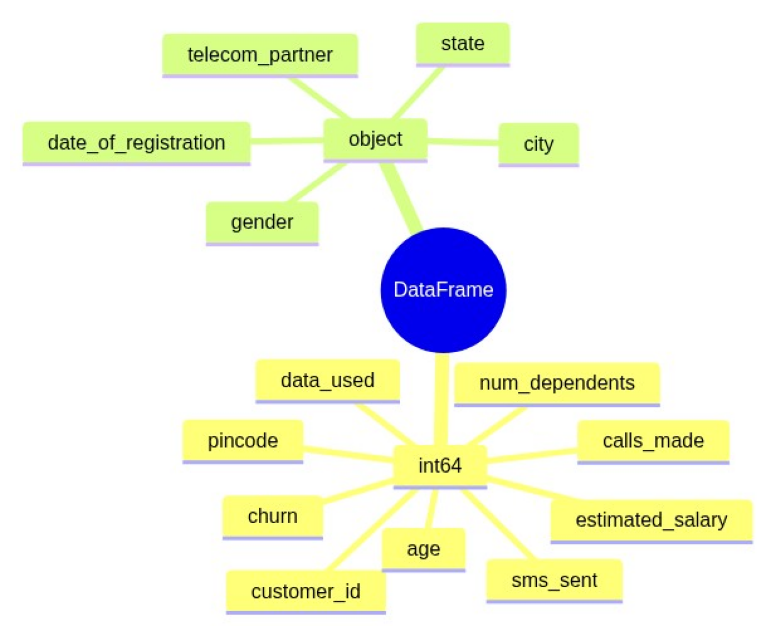

--- Missing Values ---
No missing values

Total missing: 0
--- Duplicates ---
Duplicate rows: 0
--- File Encoding ---
  Encoding:   ascii
  Confidence: 100.00%
  Language:   eo

--- Non-ASCII Characters in String Columns ---
  All string columns contain only ASCII characters
--- First 5 Rows ---
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
   customer_id telecom_partner gender  age              state     city  pincode date_of_registration  num_dependents  estimated_salary  calls_made  sms_sent  data_used  churn
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
0            1    Reliance Jio      F   25          Karnataka  Kolkata   755597           2020-01-01               4            124962          44        45       -361      0
1  

In [746]:
df = pd.read_csv(os.path.join(pwd, 'telecom_churn.csv'))
display_info(df)
mindmap_columns(df)
missing_summary(df)
duplicate_summary(df)
encoding_summary(os.path.join(pwd, 'telecom_churn.csv'))
display_rows(df)

## Data Cleanup

1. **Datetime Formatting** — Parse `date_of_registration` to datetime dtype
2. **Encoding Summary** — Detect file encoding and check for non-ASCII characters
3. **Whitespace Trimming** — Strip leading/trailing whitespace from string columns
4. **Normalize Case** — Convert string columns to uppercase
5. **Drop Columns** — Remove `customer_id` and `pincode`
6. **Range Summary** — Min, max, mean, std, and other stats for all numeric columns
7. **Count Negatives** — Check `calls_made`, `sms_sent`, `data_used` for negative values
8. **Invert Negatives** — Multiply negatives by -1 in `calls_made`, `sms_sent`, `data_used` (likely typos)

**Observation:** Inverting negatives to positives — this can be a typo

--- Column Data Types ---
  date_of_registration: object
--- date_of_registration ---
  Before: object
  After:  datetime64[ns]
  Min:    2020-01-01 00:00:00
  Max:    2023-05-04 00:00:00
  Range:  1219 days 00:00:00
  Parsed: 243553 / 243553

--- First 5 Rows ---
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
   customer_id telecom_partner gender  age              state     city  pincode date_of_registration  num_dependents  estimated_salary  calls_made  sms_sent  data_used  churn
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
0            1    Reliance Jio      F   25          Karnataka  Kolkata   755597           2020-01-01               4            124962          44        45       -361      0
1            2    Reliance Jio     

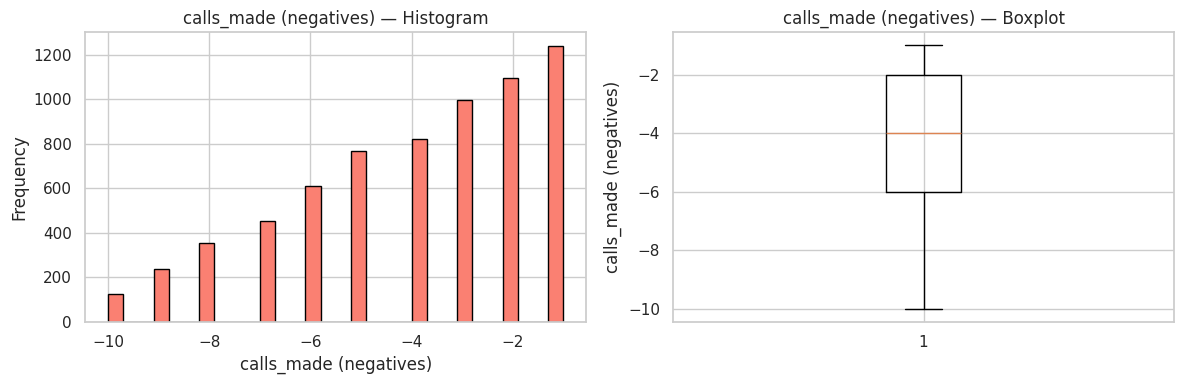

--- sms_sent ---
  Negatives:   7375
  Total:       243553
  Probability: 0.0303
  Min:         -5.0000
  Max:         -1.0000
  Mean:        -2.3233
  Median:      -2.0000
  Std:         1.2475


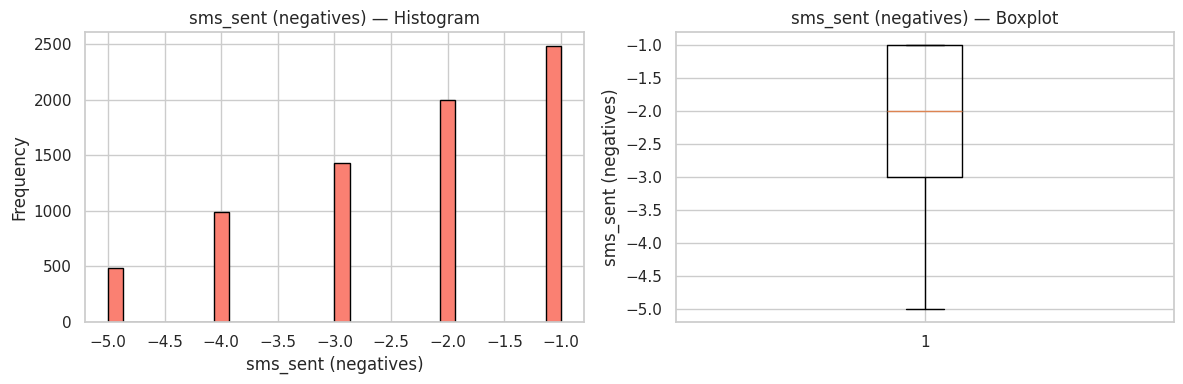

--- data_used ---
  Negatives:   6050
  Total:       243553
  Probability: 0.0248
  Min:         -987.0000
  Max:         -1.0000
  Mean:        -328.8479
  Median:      -290.0000
  Std:         234.0934


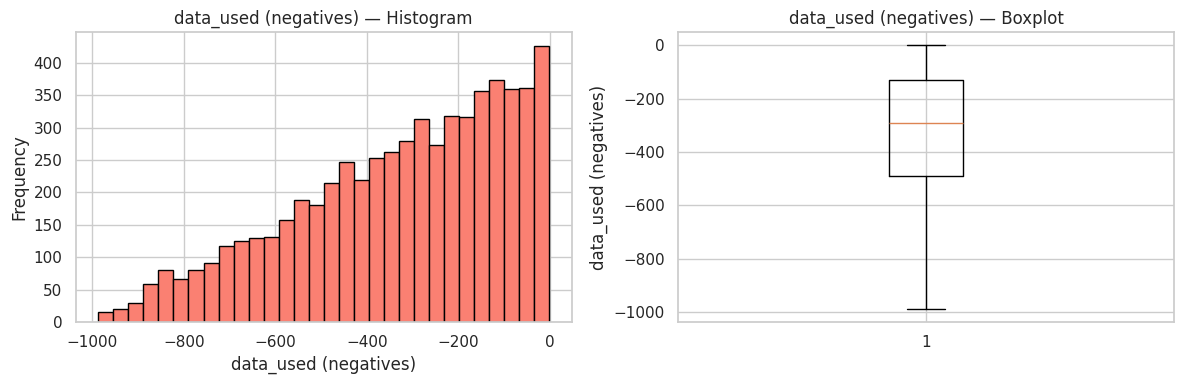

--- Invert Negatives ---
  calls_made: 6713 negatives inverted
  sms_sent: 7375 negatives inverted
  data_used: 6050 negatives inverted

--- First 5 Rows ---
--------------------------------------------------------------------------------------------------------------------------------------------------------
  telecom_partner gender  age              state     city date_of_registration  num_dependents  estimated_salary  calls_made  sms_sent  data_used  churn
--------------------------------------------------------------------------------------------------------------------------------------------------------
0    RELIANCE JIO      F   25          KARNATAKA  KOLKATA           2020-01-01               4            124962          44        45        361      0
1    RELIANCE JIO      F   55            MIZORAM   MUMBAI           2020-01-01               2            130556          62        39       5973      0
2        VODAFONE      F   57  ARUNACHAL PRADESH    DELHI           2020-01-0

In [747]:
display_column_datatype(df, ['date_of_registration'])
df = datetime_formatting(df, ['date_of_registration'])
display_column_datatype(df, ['date_of_registration'])
encoding_summary(os.path.join(pwd, 'telecom_churn.csv'))
df = whitespace_trimming(df)
df = normalize_case(df)
df = drop_columns(df, ['customer_id', 'pincode'])
display_rows(df)
range_summary(df)
count_negatives(df, 'calls_made')
count_negatives(df, 'sms_sent')
count_negatives(df, 'data_used')
# inverting negatives to positives — this can be a typo
df = invert_negatives(df, ['calls_made', 'sms_sent', 'data_used'])

## Data Classification

1. **Column Classification** — Label-encode `gender`, `telecom_partner`, `state`, `city` to numeric indices
2. **Datetime Age Classification** — Compute `registration_age` (years) from `date_of_registration`
3. **Memory Usage Impact** — Compare memory before and after classification

In [748]:
mem_before = df.memory_usage(deep=True).sum()

df, genders = column_classification(df, 'gender')
df, telecom_partners = column_classification(df, 'telecom_partner')
df, states = column_classification(df, 'state')
df, cities = column_classification(df, 'city')
df = datetime_age_classification(df, 'date_of_registration', 'registration_age')

mem_after = df.memory_usage(deep=True).sum()

print()
print("--- Memory Usage Impact ---")
print(f"  Before: {mem_before:,} bytes ({mem_before / 1024:.2f} KB)")
print(f"  After:  {mem_after:,} bytes ({mem_after / 1024:.2f} KB)")
print(f"  Saved:  {mem_before - mem_after:,} bytes ({(mem_before - mem_after) / 1024:.2f} KB)")
print(f"  Change: {(mem_after - mem_before) / mem_before * 100:.2f}%")
print()

display_rows(df)

--- gender ---
  Dtype:   object
  Unique:  2
  Mapping:
    F -> 0
    M -> 1
--- telecom_partner ---
  Dtype:   object
  Unique:  4
  Mapping:
    RELIANCE JIO -> 0
    VODAFONE -> 1
    BSNL -> 2
    AIRTEL -> 3
--- state ---
  Dtype:   object
  Unique:  28
  Mapping:
    KARNATAKA -> 0
    MIZORAM -> 1
    ARUNACHAL PRADESH -> 2
    TAMIL NADU -> 3
    TRIPURA -> 4
    UTTARAKHAND -> 5
    HIMACHAL PRADESH -> 6
    RAJASTHAN -> 7
    ODISHA -> 8
    UTTAR PRADESH -> 9
    CHHATTISGARH -> 10
    MADHYA PRADESH -> 11
    MANIPUR -> 12
    GOA -> 13
    WEST BENGAL -> 14
    GUJARAT -> 15
    TELANGANA -> 16
    MAHARASHTRA -> 17
    HARYANA -> 18
    ANDHRA PRADESH -> 19
    SIKKIM -> 20
    ASSAM -> 21
    JHARKHAND -> 22
    KERALA -> 23
    PUNJAB -> 24
    NAGALAND -> 25
    BIHAR -> 26
    MEGHALAYA -> 27
--- city ---
  Dtype:   object
  Unique:  6
  Mapping:
    KOLKATA -> 0
    MUMBAI -> 1
    DELHI -> 2
    CHENNAI -> 3
    HYDERABAD -> 4
    BANGALORE -> 5
--- registration_a

## Data Binning and Spread Analysis

--- First 5 Rows ---
-------------------------------------------------------------------------------------------------------------------------------------------------------------
   telecom_partner  gender  age  state  city date_of_registration  num_dependents  estimated_salary  calls_made  sms_sent  data_used  churn  registration_age
-------------------------------------------------------------------------------------------------------------------------------------------------------------
0                0       0   25      0     0           2020-01-01               4            124962          44        45        361      0              2300
1                0       0   55      1     1           2020-01-01               2            130556          62        39       5973      0              2300
2                1       0   57      2     2           2020-01-01               0            148828          49        24        193      1              2300
3                2       1   46

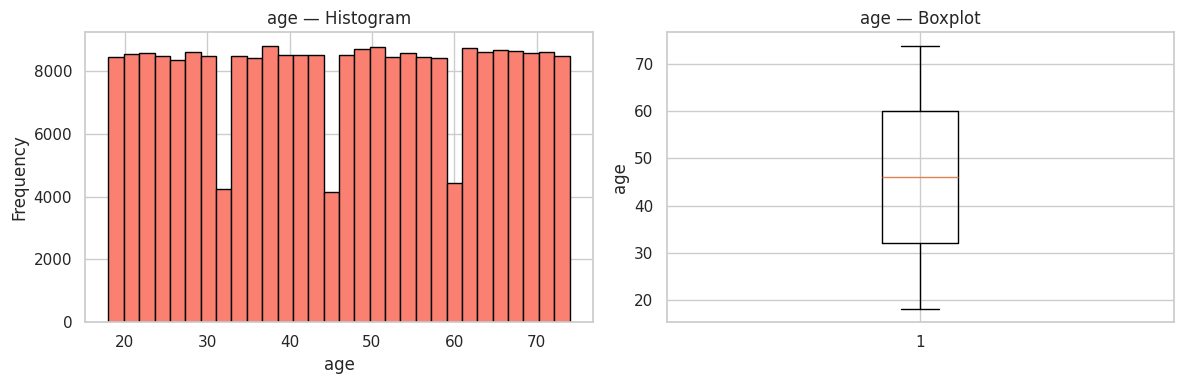

--- estimated_salary -> estimated_salary_bin ---
  Range: 20000 to 149999
  Bins:  5
    0: [20000.0, 45999.8] -> 48473 rows
    1: [45999.8, 71999.6] -> 49033 rows
    2: [71999.6, 97999.4] -> 48528 rows
    3: [97999.4, 123999.2] -> 48857 rows
    4: [123999.2, 149999.0] -> 48662 rows


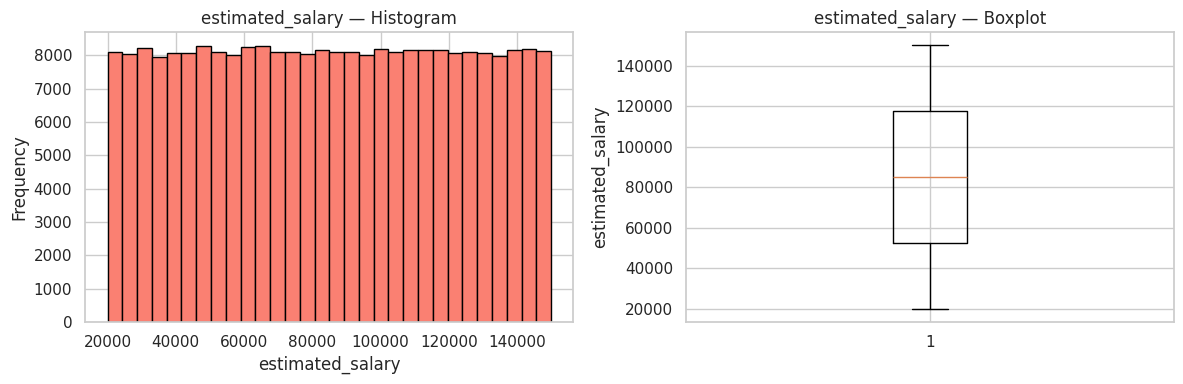

--- calls_made -> calls_made_bin ---
  Range: 0 to 108
  Bins:  5
    0: [0.0, 21.6] -> 54892 rows
    1: [21.6, 43.2] -> 53431 rows
    2: [43.2, 64.8] -> 50921 rows
    3: [64.8, 86.4] -> 53863 rows
    4: [86.4, 108.0] -> 30446 rows


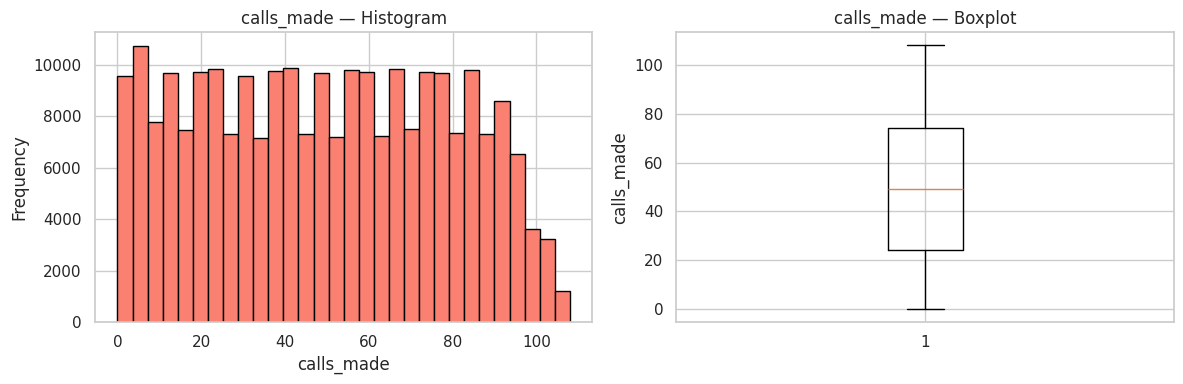

--- sms_sent -> sms_sent_bin ---
  Range: 0 to 53
  Bins:  5
    0: [0.0, 10.6] -> 56330 rows
    1: [10.6, 21.2] -> 53758 rows
    2: [21.2, 31.8] -> 48413 rows
    3: [31.8, 42.4] -> 53398 rows
    4: [42.4, 53.0] -> 31654 rows


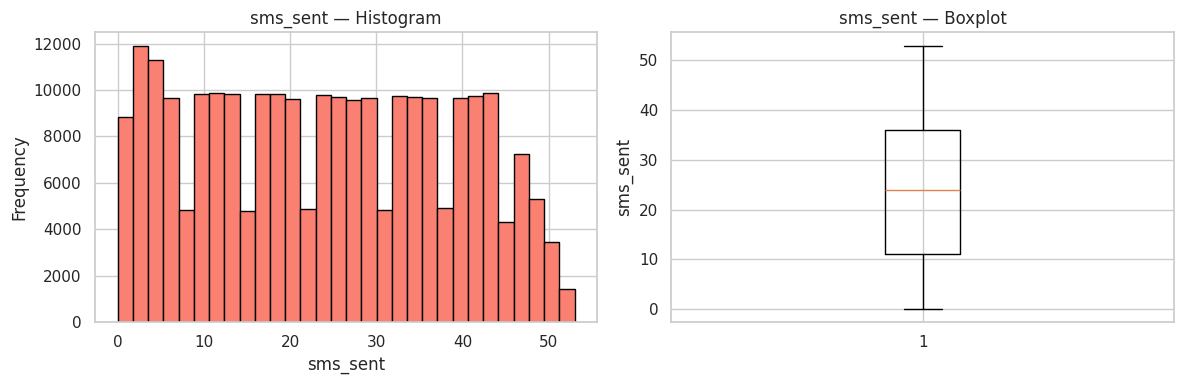

--- data_used -> data_used_bin ---
  Range: 0 to 10991
  Bins:  5
    0: [0.0, 2198.2] -> 53791 rows
    1: [2198.2, 4396.4] -> 53612 rows
    2: [4396.4, 6594.6] -> 53365 rows
    3: [6594.6, 8792.8] -> 53539 rows
    4: [8792.8, 10991.0] -> 29246 rows


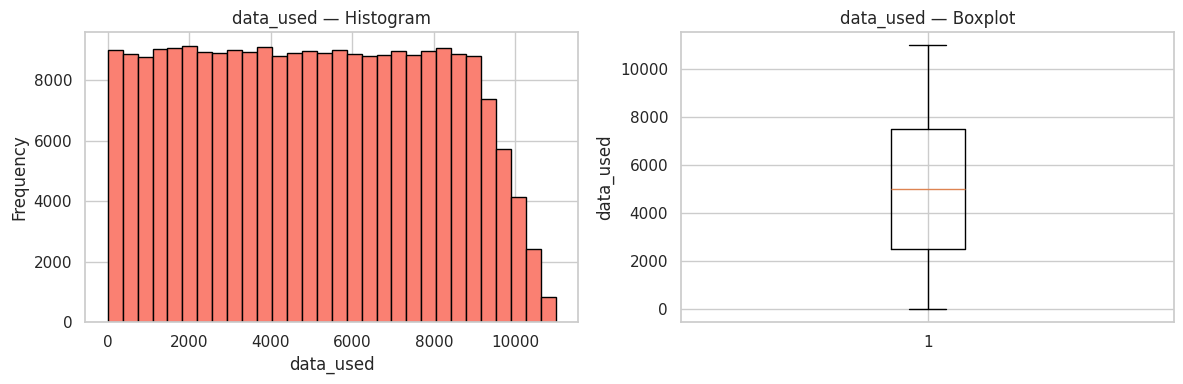

--- registration_age -> registration_age_bin ---
  Range: 1081 to 2300
  Bins:  5
    0: [1081.0, 1324.8] -> 48551 rows
    1: [1324.8, 1568.6] -> 48750 rows
    2: [1568.6, 1812.4] -> 48751 rows
    3: [1812.4, 2056.2] -> 48750 rows
    4: [2056.2, 2300.0] -> 48751 rows


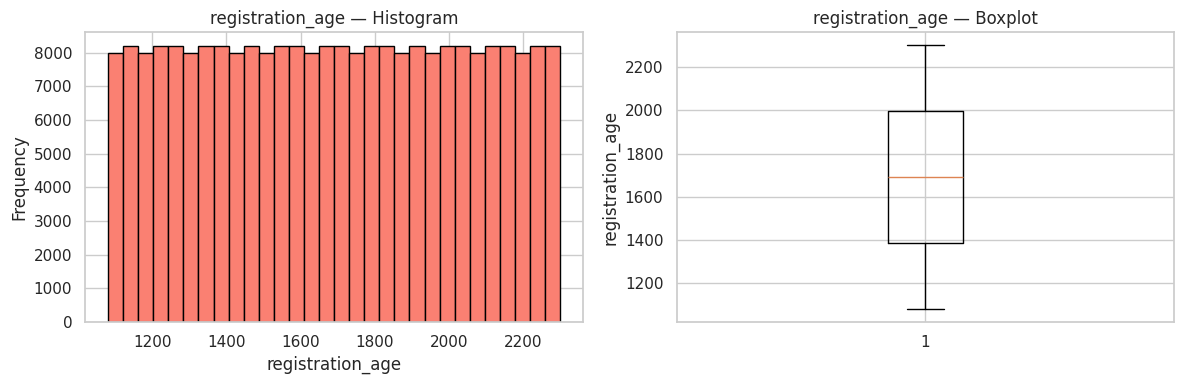

--- First 5 Rows ---
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
   telecom_partner  gender  age  state  city date_of_registration  num_dependents  estimated_salary  calls_made  sms_sent  data_used  churn  registration_age  age_bin  estimated_salary_bin  calls_made_bin  sms_sent_bin  data_used_bin  registration_age_bin
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
0                0       0   25      0     0           2020-01-01               4            124962          44        45        361      0              2300        0                     4               2       

In [749]:
display_rows(df)
columns = ['age', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used', 'registration_age']

# Create bins for all columns and store bin info
bins_info = {}
for col in columns:
    df, bins = column_binning(df, col)
    bins_info[col] = bins
    plot_spread(extract_column(df, col), col)

display_rows(df)

## Counting & Value Frequencies

1. **Count Classifications** — Count occurrences of each label-encoded value for `gender`, `telecom_partner`, `state`, `city`
2. **Pie Charts** — Visualize distributions for gender, telecom partner, state, and city

**Observation:** City and state piecharts look ambiguous; there is no coverage of many states in the city.

In [750]:
gender_counts = count_classifications(df, 'gender', genders)
telecom_partner_counts = count_classifications(df, 'telecom_partner', telecom_partners)
state_counts = count_classifications(df, 'state', states)
city_counts = count_classifications(df, 'city', cities)

horizontal_tabs({
    'Genders': lambda: piechart(gender_counts, 'Gender Distribution'),
    'Partners': lambda: piechart(telecom_partner_counts, 'Telecom Partner Distribution'),
    'States': lambda: piechart(state_counts, 'State Distribution'),
    'Cities': lambda: piechart(city_counts, 'City Distribution'),
})

# city and state piecharts look ambiguous
# there is no coverage of many states in the city

--- gender ---
  F: 97576
  M: 145977
  Total: 243553
--- telecom_partner ---
  RELIANCE JIO: 61123
  VODAFONE: 60802
  BSNL: 60723
  AIRTEL: 60905
  Total: 243553
--- state ---
  KARNATAKA: 8845
  MIZORAM: 8689
  ARUNACHAL PRADESH: 8757
  TAMIL NADU: 8718
  TRIPURA: 8660
  UTTARAKHAND: 8856
  HIMACHAL PRADESH: 8682
  RAJASTHAN: 8750
  ODISHA: 8712
  UTTAR PRADESH: 8742
  CHHATTISGARH: 8677
  MADHYA PRADESH: 8817
  MANIPUR: 8651
  GOA: 8694
  WEST BENGAL: 8572
  GUJARAT: 8610
  TELANGANA: 8689
  MAHARASHTRA: 8820
  HARYANA: 8740
  ANDHRA PRADESH: 8649
  SIKKIM: 8689
  ASSAM: 8547
  JHARKHAND: 8755
  KERALA: 8725
  PUNJAB: 8628
  NAGALAND: 8562
  BIHAR: 8633
  MEGHALAYA: 8684
  Total: 243553
--- city ---
  KOLKATA: 40661
  MUMBAI: 40386
  DELHI: 40456
  CHENNAI: 40749
  HYDERABAD: 40698
  BANGALORE: 40603
  Total: 243553


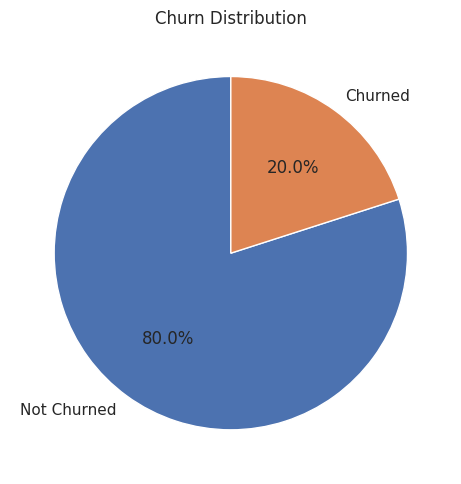

In [751]:
df_churned = filter_dataframe(df, 'churn == 1')
df_churned_c = filter_dataframe(df, 'churn != 1')
# print(f"Churned customers: {len(df_churned)} rows")
# display_rows(df_churned)
# print(f"Churned customers: {len(df_churned_c)} rows")
# display_rows(df_churned_c)

churn_counts = {
    'Not Churned': (df['churn'] == 0).sum(),
    'Churned': (df['churn'] == 1).sum()
}
piechart(churn_counts, 'Churn Distribution')



## Analysis of `Gender` `State` `City` `Telecom Partner` on Churn

### Key Observations

**No Strong Predictive Power:** The demographic and service attributes (`Gender`, `State`, `City`, `Telecom Partner`) show minimal discriminative power for predicting churn. The probability distributions are nearly identical between churned and not-churned customer groups, indicating these features are not major churn drivers.

**Balanced Distribution Across Groups:** When a category's percentage among churned customers matches its percentage among not-churned customers, it suggests the category is equally represented in both groups regardless of churn status. This signals weak correlation with churn behavior.

**Implications:**
- `Gender` distribution among churned customers closely mirrors the overall customer gender distribution
- `Telecom Partner` categories are proportionally represented in both churned and not-churned groups
- Geographic factors (`State`, `City`) don't show concentrations of churn in specific regions
- **Conclusion:** Churn appears to be driven by factors beyond these demographics - likely service-related metrics (contract type, tenure, monthly charges, service usage patterns) or behavioral indicators rather than customer characteristics

In [752]:
gender_counts_churned = count_classifications(df_churned, 'gender', genders, verbose=False)
telecom_partner_counts_churned = count_classifications(df_churned, 'telecom_partner', telecom_partners, verbose=False)
state_counts_churned = count_classifications(df_churned, 'state', states, verbose=False)
city_counts_churned = count_classifications(df_churned, 'city', cities, verbose=False)

gender_counts_not_churned = count_classifications(df_churned_c, 'gender', genders, verbose=False)
telecom_partner_counts_not_churned = count_classifications(df_churned_c, 'telecom_partner', telecom_partners, verbose=False)
state_counts_not_churned = count_classifications(df_churned_c, 'state', states, verbose=False)
city_counts_not_churned = count_classifications(df_churned_c, 'city', cities, verbose=False)

# Print churned vs not churned with probabilities
def print_churn_comparison(counts_churned, counts_not_churned, title):
    print(f"\n--- {title} ---")
    print(f"{'Category':<20} {'Churned':<12} {'Not Churned':<15} {'Total':<8} {'Churn %':<10}")
    print("-" * 70)
    
    total_churned = 0
    total_not_churned = 0
    
    for cat in counts_churned.keys():
        churned = counts_churned[cat]
        not_churned = counts_not_churned[cat]
        total = churned + not_churned
        churn_pct = (churned / total * 100) if total > 0 else 0
        
        total_churned += churned
        total_not_churned += not_churned
        
        print(f"{cat:<20} {churned:<12} {not_churned:<15} {total:<8} {churn_pct:<10.2f}%")
    
    total_all = total_churned + total_not_churned
    overall_churn_pct = (total_churned / total_all * 100) if total_all > 0 else 0
    print("-" * 70)
    print(f"{'TOTAL':<20} {total_churned:<12} {total_not_churned:<15} {total_all:<8} {overall_churn_pct:<10.2f}%")

# Print category probabilities within churned and not churned groups
def print_category_probabilities(counts_churned, counts_not_churned, title):
    print(f"\n{'='*70}")
    print(f"PROBABILITY DISTRIBUTION: {title}")
    print(f"{'='*70}")
    
    total_churned = sum(counts_churned.values())
    total_not_churned = sum(counts_not_churned.values())
    
    print(f"\n--- Within CHURNED Customers (n={total_churned}) ---")
    print(f"{'Category':<25} {'Count':<10} {'Probability':<12}")
    print("-" * 50)
    for cat, count in counts_churned.items():
        prob = (count / total_churned * 100) if total_churned > 0 else 0
        print(f"{cat:<25} {count:<10} {prob:<12.2f}%")
    
    print(f"\n--- Within NOT CHURNED Customers (n={total_not_churned}) ---")
    print(f"{'Category':<25} {'Count':<10} {'Probability':<12}")
    print("-" * 50)
    for cat, count in counts_not_churned.items():
        prob = (count / total_not_churned * 100) if total_not_churned > 0 else 0
        print(f"{cat:<25} {count:<10} {prob:<12.2f}%")

print("\n" + "="*70)
print("CHURN ANALYSIS: COUNTS AND PROBABILITIES")
print("="*70)

print_churn_comparison(gender_counts_churned, gender_counts_not_churned, "GENDER")
print_churn_comparison(telecom_partner_counts_churned, telecom_partner_counts_not_churned, "TELECOM PARTNER")
print_churn_comparison(state_counts_churned, state_counts_not_churned, "STATE")
print_churn_comparison(city_counts_churned, city_counts_not_churned, "CITY")

print("\n\n" + "="*70)
print("PROBABILITY DISTRIBUTION WITHIN CHURN GROUPS")
print("="*70)

print_category_probabilities(gender_counts_churned, gender_counts_not_churned, "GENDER")
print_category_probabilities(telecom_partner_counts_churned, telecom_partner_counts_not_churned, "TELECOM PARTNER")
print_category_probabilities(state_counts_churned, state_counts_not_churned, "STATE")
print_category_probabilities(city_counts_churned, city_counts_not_churned, "CITY")

print("\n" + "="*70)
print("CHURN VISUALIZATION: 100% STACKED BAR CHARTS")
print("="*70 + "\n")

horizontal_tabs({
    'Gender': lambda: stacked_bar_comparison(gender_counts_churned, gender_counts_not_churned, 'Gender'),
    'Partner': lambda: stacked_bar_comparison(telecom_partner_counts_churned, telecom_partner_counts_not_churned, 'Telecom Partner'),
    'State': lambda: stacked_bar_comparison(state_counts_churned, state_counts_not_churned, 'State'),
    'City': lambda: stacked_bar_comparison(city_counts_churned, city_counts_not_churned, 'City'),
})


CHURN ANALYSIS: COUNTS AND PROBABILITIES

--- GENDER ---
Category             Churned      Not Churned     Total    Churn %   
----------------------------------------------------------------------
F                    19805        77771           97576    20.30     %
M                    29022        116955          145977   19.88     %
----------------------------------------------------------------------
TOTAL                48827        194726          243553   20.05     %

--- TELECOM PARTNER ---
Category             Churned      Not Churned     Total    Churn %   
----------------------------------------------------------------------
RELIANCE JIO         12234        48889           61123    20.02     %
VODAFONE             12129        48673           60802    19.95     %
BSNL                 12060        48663           60723    19.86     %
AIRTEL               12404        48501           60905    20.37     %
-------------------------------------------------------------------

## Churn Analysis by Binned Features

### Key Observation

**No single feature shows strong predictive power for churn.** Across all analyzed features — age, registration age, estimated salary, number of dependents, calls made, SMS sent, and data used — churn probability is equally distributed across all bins/groups. None of these demographic, financial, or usage-based characteristics are strong discriminators for predicting customer churn. This suggests churn is driven by factors not captured in these features, such as contract terms, service quality, billing experiences, or customer satisfaction.

In [753]:
def _churn_row(df_subset, label):
    """Build a single churn-analysis row from a DataFrame subset."""
    df_churned = df_subset[df_subset['churn'] == 1]
    churned_count = len(df_churned)
    not_churned_count = len(df_subset) - churned_count
    total = len(df_subset)
    churn_pct = (churned_count / total * 100) if total > 0 else 0

    female_pct = (df_churned['gender'] == 0).sum() / churned_count * 100 if churned_count > 0 else 0
    male_pct = (df_churned['gender'] == 1).sum() / churned_count * 100 if churned_count > 0 else 0

    row = {
        'Range': label,
        'Churned': churned_count,
        'Not Churned': not_churned_count,
        'Total': total,
        'Churn %': round(churn_pct, 2),
        'Female %': round(female_pct, 2),
        'Male %': round(male_pct, 2),
    }

    for i, city in enumerate(cities):
        city_pct = (df_churned['city'] == i).sum() / churned_count * 100 if churned_count > 0 else 0
        row[f'{city} %'] = round(city_pct, 2)

    for i, partner in enumerate(telecom_partners):
        partner_pct = (df_churned['telecom_partner'] == i).sum() / churned_count * 100 if churned_count > 0 else 0
        row[f'{partner} %'] = round(partner_pct, 2)

    return row


def bin_churn_analysis(df, column_name, bins_list, label_fmt=None):
    """
    Analyze churn rates per bin for a binned column.
    Uses '{column_name}_bin' column and bins_list from bins_info.
    Returns a DataFrame with churn stats per bin.
    
    label_fmt: optional callable(start, end) -> str for custom bin labels.
               Defaults to "{start}-{end}".
    """
    bin_col = f"{column_name}_bin"
    if label_fmt is None:
        label_fmt = lambda s, e: f"{s}-{e}"

    data = []
    for bin_idx in range(len(bins_list)):
        start, end = bins_list[bin_idx]
        label = label_fmt(start, end)
        df_bin = df[df[bin_col] == bin_idx]
        data.append(_churn_row(df_bin, label))

    result_df = pd.DataFrame(data)
    display_rows(result_df, n=len(bins_list))
    return result_df


def unique_value_churn_analysis(df, column_name):
    """
    Analyze churn rates per unique value (e.g. num_dependents).
    Returns a DataFrame with churn stats per unique value.
    """
    unique_vals = sorted(df[column_name].dropna().unique().tolist())

    data = []
    for val in unique_vals:
        df_val = df[df[column_name] == val]
        data.append(_churn_row(df_val, val))

    result_df = pd.DataFrame(data)
    display_rows(result_df, n=len(unique_vals))
    return result_df

In [754]:
age_churn_df = bin_churn_analysis(df, 'age', bins_info['age'])

--- All 5 Rows ---
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
       Range  Churned  Not Churned  Total  Churn %  Female %  Male %  KOLKATA %  MUMBAI %  DELHI %  CHENNAI %  HYDERABAD %  BANGALORE %  RELIANCE JIO %  VODAFONE %  BSNL %  AIRTEL %
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
0  18.0-29.2    10072        40887  50959    19.76     40.76   59.24      16.83     15.84    17.04      16.00        17.22        17.08           25.19       25.68   24.21     24.93
1  29.2-40.4     9536        37338  46874    20.34     40.15   59.85      16.46     16.83    16.38      17.01        16.67        16.64           25.13       24.09   24.80     25.99
2  40.4-51.6     9430        37687  47117    20.01     40.59   59.41   

In [755]:
registration_age_churn_df = bin_churn_analysis(df, 'registration_age', bins_info['registration_age'])

--- All 5 Rows ---
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
           Range  Churned  Not Churned  Total  Churn %  Female %  Male %  KOLKATA %  MUMBAI %  DELHI %  CHENNAI %  HYDERABAD %  BANGALORE %  RELIANCE JIO %  VODAFONE %  BSNL %  AIRTEL %
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
0  1081.0-1324.8     9749        38802  48551    20.08     40.97   59.03      16.95     16.31    16.22      17.02        16.79        16.72           25.01       25.06   24.19     25.75
1  1324.8-1568.6     9774        38976  48750    20.05     40.62   59.38      16.86     16.72    16.26      16.79        16.87        16.50           25.69       24.28   24.58     25.46
2  1568.6-1812.4     9833        38918  48751    20

In [756]:
salary_churn_df = bin_churn_analysis(df, 'estimated_salary', bins_info['estimated_salary'],
                                     label_fmt=lambda s, e: f"₹{int(s):,}-₹{int(e):,}")

--- All 5 Rows ---
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
               Range  Churned  Not Churned  Total  Churn %  Female %  Male %  KOLKATA %  MUMBAI %  DELHI %  CHENNAI %  HYDERABAD %  BANGALORE %  RELIANCE JIO %  VODAFONE %  BSNL %  AIRTEL %
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
0    ₹20,000-₹45,999     9783        38690  48473    20.18     40.26   59.74      16.73     16.55    16.52      16.53        16.91        16.76           24.63       25.10   24.86     25.40
1    ₹45,999-₹71,999     9814        39219  49033    20.02     40.16   59.84      16.66     16.01    16.60      16.78        17.54        16.42           25.46       24.94   25.14     24.45
2    ₹71,999-₹97,999     9847  

In [757]:
dependents_churn_df = unique_value_churn_analysis(df, 'num_dependents')

--- All 5 Rows ---
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
   Range  Churned  Not Churned  Total  Churn %  Female %  Male %  KOLKATA %  MUMBAI %  DELHI %  CHENNAI %  HYDERABAD %  BANGALORE %  RELIANCE JIO %  VODAFONE %  BSNL %  AIRTEL %
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
0      0     9900        39027  48927    20.23     39.55   60.45      17.01     17.00    16.20      16.44        16.52        16.83           24.95       24.88   24.99     25.18
1      1     9815        38886  48701    20.15     41.26   58.74      17.04     17.19    16.01      16.71        17.10        15.97           25.50       24.87   24.04     25.58
2      2     9719        38886  48605    20.00     40.67   59.33      16.72     16.49    15

In [758]:
calls_churn_df = bin_churn_analysis(df, 'calls_made', bins_info['calls_made'],
                                    label_fmt=lambda s, e: f"{int(s)}-{int(e)}")

--- All 5 Rows ---
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    Range  Churned  Not Churned  Total  Churn %  Female %  Male %  KOLKATA %  MUMBAI %  DELHI %  CHENNAI %  HYDERABAD %  BANGALORE %  RELIANCE JIO %  VODAFONE %  BSNL %  AIRTEL %
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
0    0-21    10937        43955  54892    19.92     40.68   59.32      16.22     16.48    16.68      16.73        17.32        16.58           24.98       25.41   24.58     25.03
1   21-43    10666        42765  53431    19.96     40.32   59.68      17.04     16.97    16.46      16.19        16.65        16.69           25.34       24.39   24.79     25.48
2   43-64    10194        40727  50921    20.02     40.62   59.38      16.91     16.60

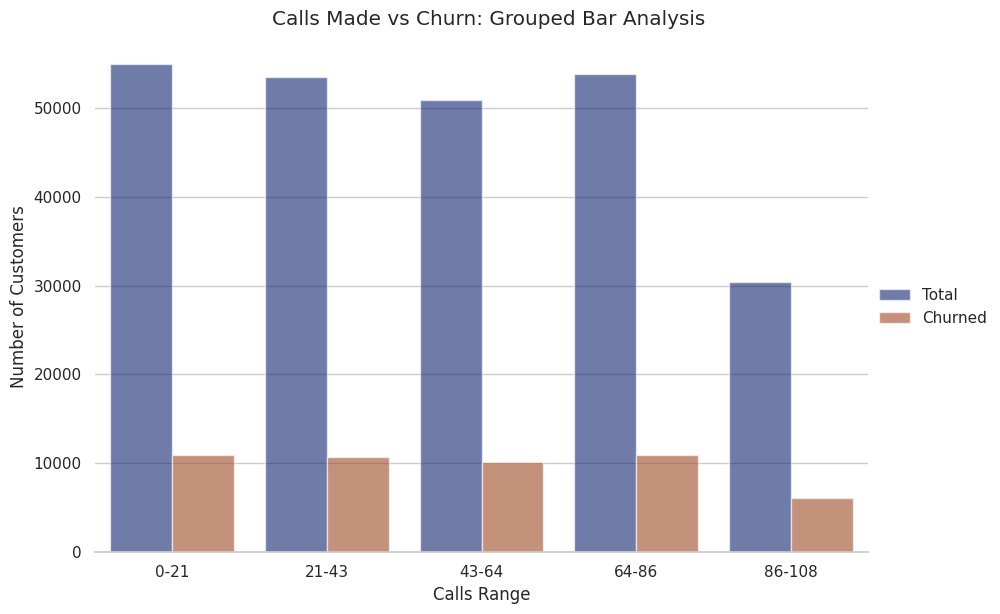

In [759]:
grouped_barplot(
    calls_churn_df,
    category_col="Range",
    value_cols=["Total", "Churned"],
    title="Calls Made vs Churn: Grouped Bar Analysis",
    xlabel="Calls Range",
    ylabel="Number of Customers"
)

In [760]:
sms_churn_df = bin_churn_analysis(df, 'sms_sent', bins_info['sms_sent'],
                                  label_fmt=lambda s, e: f"{int(s)}-{int(e)}")

--- All 5 Rows ---
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
   Range  Churned  Not Churned  Total  Churn %  Female %  Male %  KOLKATA %  MUMBAI %  DELHI %  CHENNAI %  HYDERABAD %  BANGALORE %  RELIANCE JIO %  VODAFONE %  BSNL %  AIRTEL %
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
0   0-10    11381        44949  56330    20.20     41.26   58.74      17.13     16.14    16.41      16.64        17.11        16.56           25.01       25.10   24.31     25.58
1  10-21    10794        42964  53758    20.08     40.64   59.36      16.61     16.12    16.47      16.72        17.31        16.77           25.22       24.87   24.64     25.27
2  21-31     9764        38649  48413    20.17     40.44   59.56      17.04     17.07    16

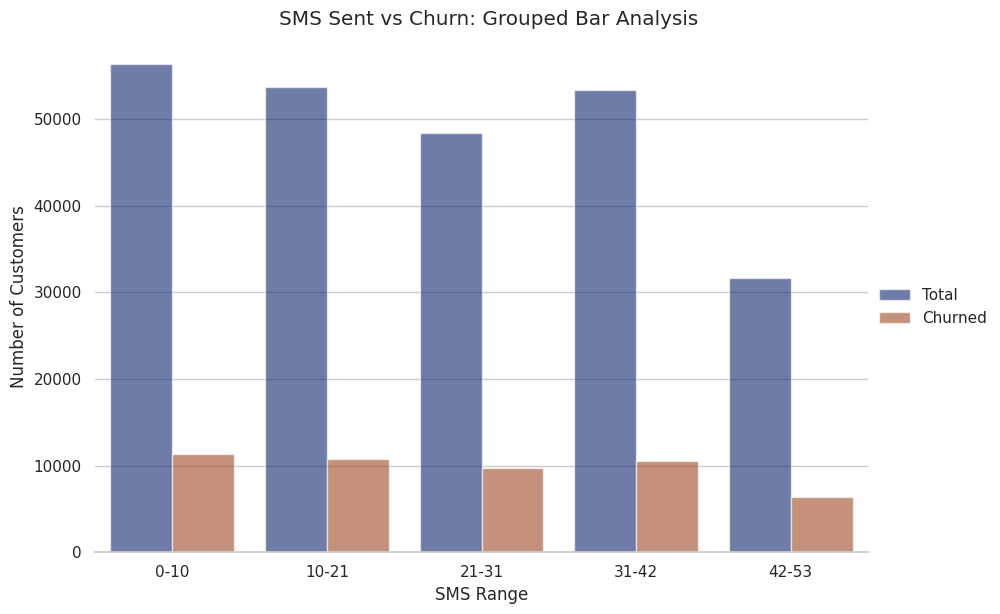

In [761]:
grouped_barplot(
    sms_churn_df,
    category_col="Range",
    value_cols=["Total", "Churned"],
    title="SMS Sent vs Churn: Grouped Bar Analysis",
    xlabel="SMS Range",
    ylabel="Number of Customers"
)

In [762]:
data_churn_df = bin_churn_analysis(df, 'data_used', bins_info['data_used'],
                                   label_fmt=lambda s, e: f"{int(s)}-{int(e)}")

--- All 5 Rows ---
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
        Range  Churned  Not Churned  Total  Churn %  Female %  Male %  KOLKATA %  MUMBAI %  DELHI %  CHENNAI %  HYDERABAD %  BANGALORE %  RELIANCE JIO %  VODAFONE %  BSNL %  AIRTEL %
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
0      0-2198    10665        43126  53791    19.83     41.11   58.89      16.16     17.24    16.79      16.38        16.70        16.73           25.28       24.06   25.16     25.50
1   2198-4396    10797        42815  53612    20.14     40.68   59.32      16.94     16.74    16.76      16.75        16.71        16.11           25.03       24.85   24.28     25.83
2   4396-6594    10760        42605  53365    20.16     40.37   59

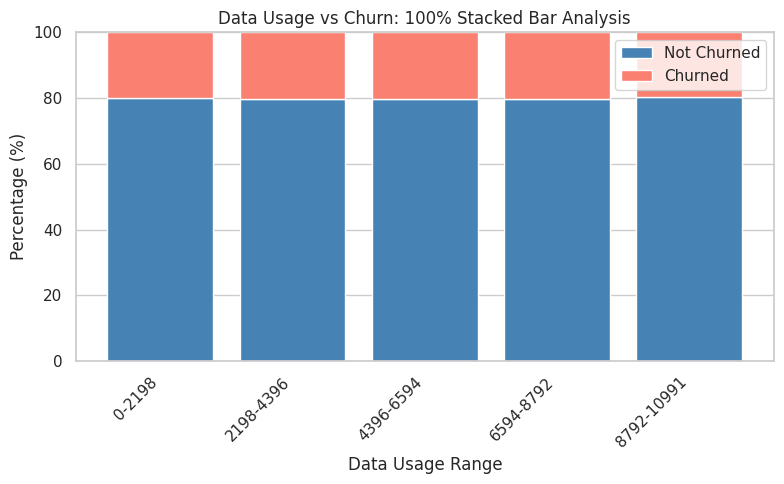

In [763]:
stacked_barplot(
    data_churn_df,
    category_col="Range",
    value_cols=["Not Churned", "Churned"],
    title="Data Usage vs Churn: 100% Stacked Bar Analysis",
    xlabel="Data Usage Range",
    colors=["steelblue", "salmon"],
)

## Principal Component Analysis

1. **Dimensionality Reduction** — 12 numeric features reduced to 1 principal component (PC1) using StandardScaler + PCA
2. **PC1 Variance Explained** — PC1 captures only **16.50%** of total variance, meaning the features are spread across many dimensions with no single dominant direction
3. **Correlation Matrix Determinant** — det = **0.0401**, indicating moderate multicollinearity among features (closer to 0 = higher multicollinearity)
4. **Linear Regression (PC1 vs Churn)** — Fitted a linear model: `Churn = 0.2005 − 0.0010 × PC1`
   - **R² = 0.000011** — PC1 explains virtually none of the variance in churn
   - **RMSE = 0.4004** — prediction error is high relative to binary churn values (0/1)
   - **Coefficient = −0.0010** — near-zero slope confirms no linear relationship

### Key Observation

**PC1 has no predictive power for churn.** The near-zero R² (0.001%) confirms that the first principal component of customer features (demographics, usage, geography) does not linearly predict churn. Combined with the earlier per-feature analysis, this reinforces that **churn is not driven by any linear combination of the available numeric features**. Predictive modeling for this dataset would likely require non-linear methods or additional features (e.g., contract type, service quality, billing history).

In [764]:
display_rows(df)
columns = ['date_of_registration', 'age_bin', 'calls_made_bin', 'sms_sent_bin', 'data_used_bin', 'registration_age_bin']

df_pca = df.copy()
df_pca = df_pca.drop(columns=columns)

print(f"Original columns: {len(df.columns)}")
print(f"Columns to remove: {len(columns)}")
print(f"Remaining columns: {len(df_pca.columns)}")

churn_target = df_pca['churn']
df_pca = df_pca.drop(columns=['churn'])

pca_result_df = run_pca(df_pca, 1)
display_rows(pca_result_df)

# Calculate determinant of df_pca
print("\n--- Determinant Analysis ---")
print(f"df_pca shape: {df_pca.shape}")
if df_pca.shape[0] == df_pca.shape[1]:
    det = np.linalg.det(df_pca.values)
    print(f"Determinant of df_pca: {det:.6f}")
else:
    print(f"Matrix is non-square ({df_pca.shape[0]} x {df_pca.shape[1]}), computing determinant of correlation matrix:")
    corr_matrix = df_pca.corr()
    det = np.linalg.det(corr_matrix.values)
    print(f"Determinant of correlation matrix: {det:.6f}")
    print(f"Correlation matrix shape: {corr_matrix.shape}")

--- First 5 Rows ---
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
   telecom_partner  gender  age  state  city date_of_registration  num_dependents  estimated_salary  calls_made  sms_sent  data_used  churn  registration_age  age_bin  estimated_salary_bin  calls_made_bin  sms_sent_bin  data_used_bin  registration_age_bin
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
0                0       0   25      0     0           2020-01-01               4            124962          44        45        361      0              2300        0                     4               2       

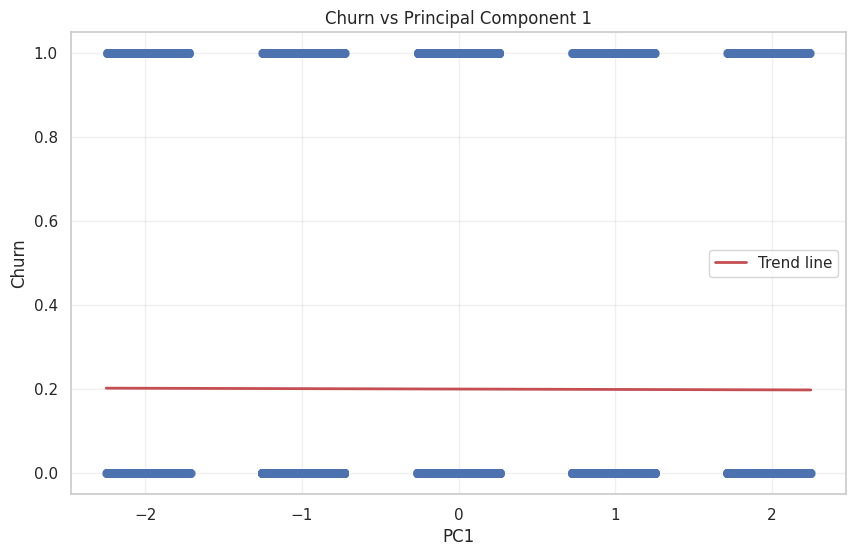

In [765]:
def plotxy(x, y, title=None, xlabel='X', ylabel='Y', trendline=True):
    """Plot x vs y scatter plot with optional trend line."""
    plt.figure(figsize=(10, 6))
    plt.scatter(x, y, alpha=0.5, s=30)
    
    if trendline:
        # Fit a polynomial (degree 1 = linear) to the data
        z = np.polyfit(x, y, 1)
        p = np.poly1d(z)
        x_sorted = np.sort(x)
        plt.plot(x_sorted, p(x_sorted), "r-", linewidth=2, label='Trend line')
        plt.legend()
    
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if title:
        plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

plotxy(pca_result_df['PC1'], churn_target, title='Churn vs Principal Component 1', xlabel='PC1', ylabel='Churn', trendline=True)

In [781]:
# Prepare data for linear regression
X = pca_result_df[['PC1']].values
y = churn_target.values

# Fit the model
model = LinearRegression()
model.fit(X, y)

# Make predictions
y_pred = model.predict(X)

# Calculate metrics
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

# Display results
print("--- Linear Regression: PC1 vs Churn ---")
print(f"  Coefficient (PC1):  {model.coef_[0]:.6f}")
print(f"  Intercept:          {model.intercept_:.6f}")
print(f"  R² Score:           {r2:.6f}")
print(f"  Mean Squared Error: {mse:.6f}")
print(f"  RMSE:               {rmse:.6f}")
print()
print(f"Regression Equation: Churn = {model.intercept_:.6f} + {model.coef_[0]:.6f} × PC1")

--- Linear Regression: PC1 vs Churn ---
  Coefficient (PC1):  -0.000950
  Intercept:          0.200478
  R² Score:           0.000011
  Mean Squared Error: 0.160285
  RMSE:               0.400356

Regression Equation: Churn = 0.200478 + -0.000950 × PC1


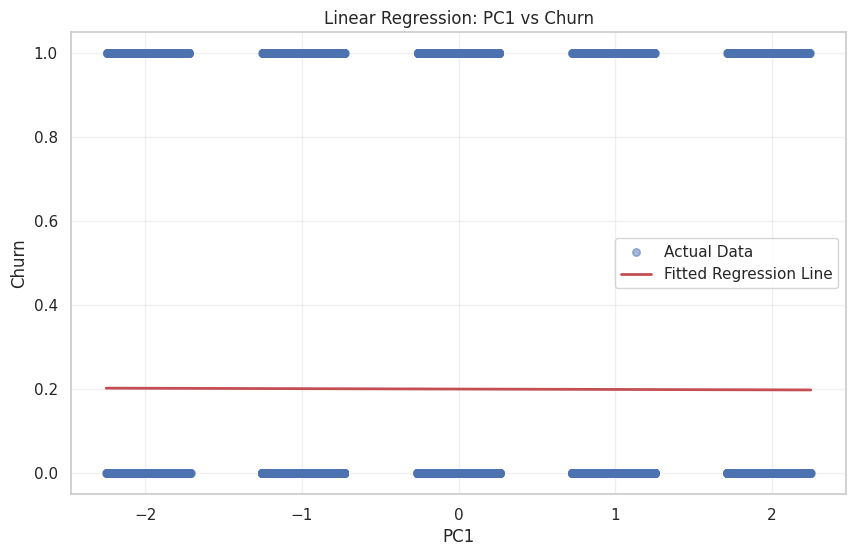

In [767]:
plt.figure(figsize=(10, 6))

# Plot scatter points
plt.scatter(X, y, alpha=0.5, s=30, label='Actual Data')

# Plot regression line
x_line = np.linspace(X.min(), X.max(), 100)
y_line = model.predict(x_line.reshape(-1, 1))
plt.plot(x_line, y_line, 'r-', linewidth=2, label='Fitted Regression Line')

plt.xlabel('PC1')
plt.ylabel('Churn')
plt.title('Linear Regression: PC1 vs Churn')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Correlation Heatmap

Visualize pairwise correlations between all numeric features including churn to identify potential relationships at a glance.

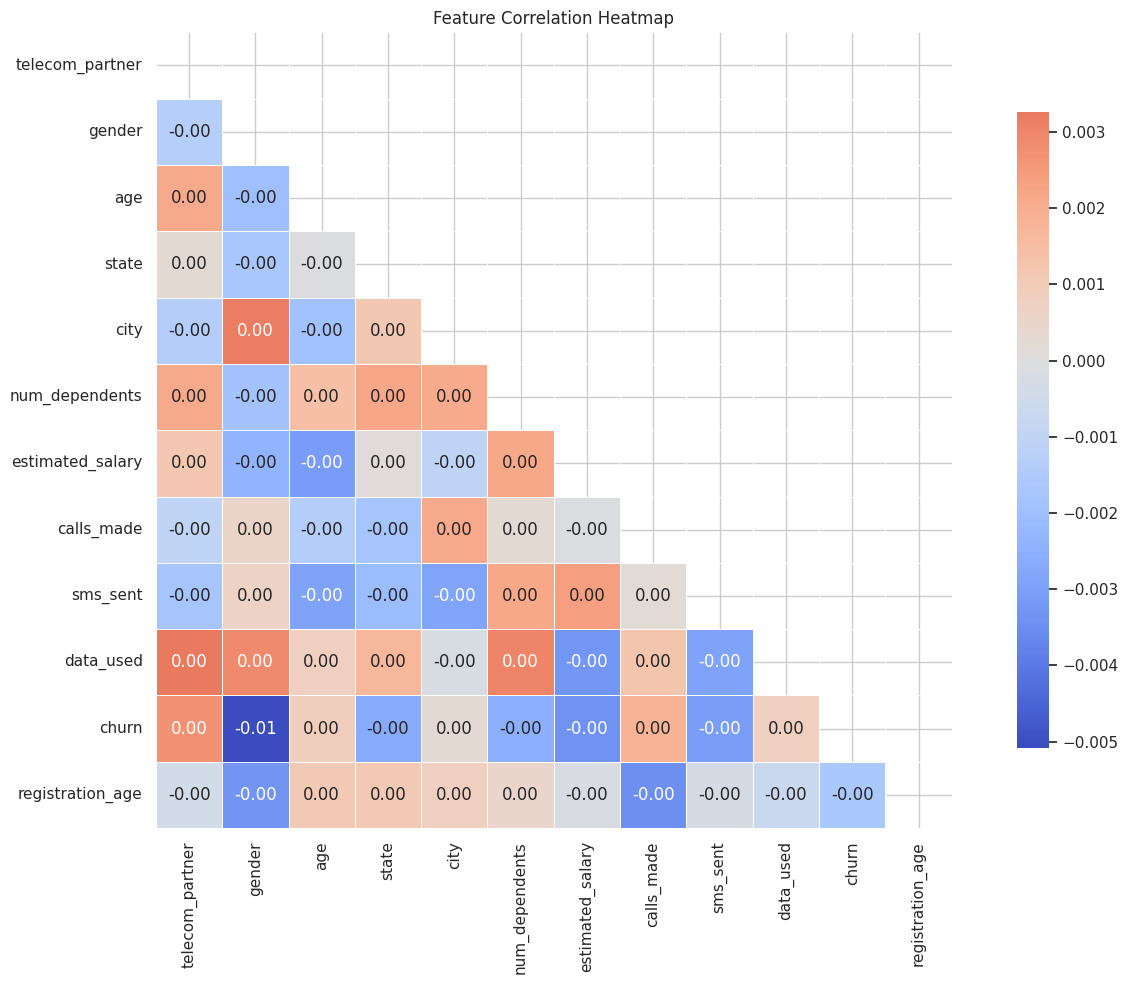

--- Correlation with Churn (|r|) ---
  gender                    0.0051
  estimated_salary          0.0033
  sms_sent                  0.0031
  state                     0.0027
  telecom_partner           0.0027
  num_dependents            0.0025
  calls_made                0.0018
  registration_age          0.0017
  age                       0.0008
  data_used                 0.0008
  city                      0.0003


In [770]:
# Drop bin columns and date for a clean correlation matrix
corr_cols = [c for c in df.columns if not c.endswith('_bin') and c != 'date_of_registration']
corr_df = df[corr_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Print correlations with churn, sorted by absolute value
churn_corr = corr_df['churn'].drop('churn').abs().sort_values(ascending=False)
print("--- Correlation with Churn (|r|) ---")
for feat, val in churn_corr.items():
    print(f"  {feat:<25} {val:.4f}")

## Logistic Regression

Churn is a binary outcome (0/1), making logistic regression the appropriate linear model. Uses train/test split for proper evaluation.

In [782]:
# Prepare features — drop bin columns, date, and target
feature_cols = [c for c in df.columns if not c.endswith('_bin') and c not in ['date_of_registration', 'churn']]
X_all = df[feature_cols].values
y_all = df['churn'].values

# Train/test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# Standardize features
scaler_lr = StandardScaler()
X_train_scaled = scaler_lr.fit_transform(X_train)
X_test_scaled = scaler_lr.transform(X_test)

print(f"Train set: {X_train.shape[0]} rows, Test set: {X_test.shape[0]} rows")
print(f"Train churn rate: {y_train.mean():.4f}")
print(f"Test churn rate:  {y_test.mean():.4f}")
print(f"Features: {feature_cols}")

Train set: 194842 rows, Test set: 48711 rows
Train churn rate: 0.2005
Test churn rate:  0.2005
Features: ['telecom_partner', 'gender', 'age', 'state', 'city', 'num_dependents', 'estimated_salary', 'calls_made', 'sms_sent', 'data_used', 'registration_age']


In [783]:
# Fit Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print_model_metrics('Logistic Regression', y_test, y_pred_lr)
print_feature_coefficients(feature_cols, lr_model.coef_[0], title="Feature Coefficients (Log-Odds)")

--- Logistic Regression ---
  Accuracy:  0.7995
  Precision: 0.0000
  Recall:    0.0000
  F1 Score:  0.0000

              precision    recall  f1-score   support

 Not Churned       0.80      1.00      0.89     38946
     Churned       0.00      0.00      0.00      9765

    accuracy                           0.80     48711
   macro avg       0.40      0.50      0.44     48711
weighted avg       0.64      0.80      0.71     48711

--- Feature Coefficients (Log-Odds) ---
  gender                    -0.013949
  estimated_salary          -0.009807
  num_dependents            -0.008147
  sms_sent                  -0.007267
  state                     -0.005732
  age                       +0.005365
  registration_age          -0.004760
  calls_made                +0.002772
  telecom_partner           +0.002519
  city                      -0.001303
  data_used                 +0.000466


## Decision Tree & Random Forest

Non-linear models that can capture feature interactions. Random Forest also provides feature importance rankings.

In [784]:
# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print_model_metrics('Decision Tree (max_depth=5)', y_test, y_pred_dt)

--- Decision Tree (max_depth=5) ---
  Accuracy:  0.7994
  Precision: 0.2308
  Recall:    0.0003
  F1 Score:  0.0006

              precision    recall  f1-score   support

 Not Churned       0.80      1.00      0.89     38946
     Churned       0.23      0.00      0.00      9765

    accuracy                           0.80     48711
   macro avg       0.52      0.50      0.44     48711
weighted avg       0.69      0.80      0.71     48711



--- Random Forest (100 trees, max_depth=10) ---
  Accuracy:  0.7995
  Precision: 0.0000
  Recall:    0.0000
  F1 Score:  0.0000

              precision    recall  f1-score   support

 Not Churned       0.80      1.00      0.89     38946
     Churned       0.00      0.00      0.00      9765

    accuracy                           0.80     48711
   macro avg       0.40      0.50      0.44     48711
weighted avg       0.64      0.80      0.71     48711

--- Feature Importance ---
  estimated_salary          0.1703
  data_used                 0.1622
  registration_age          0.1457
  calls_made                0.1156
  sms_sent                  0.0993
  age                       0.0960
  state                     0.0816
  city                      0.0436
  num_dependents            0.0386
  telecom_partner           0.0331
  gender                    0.0140


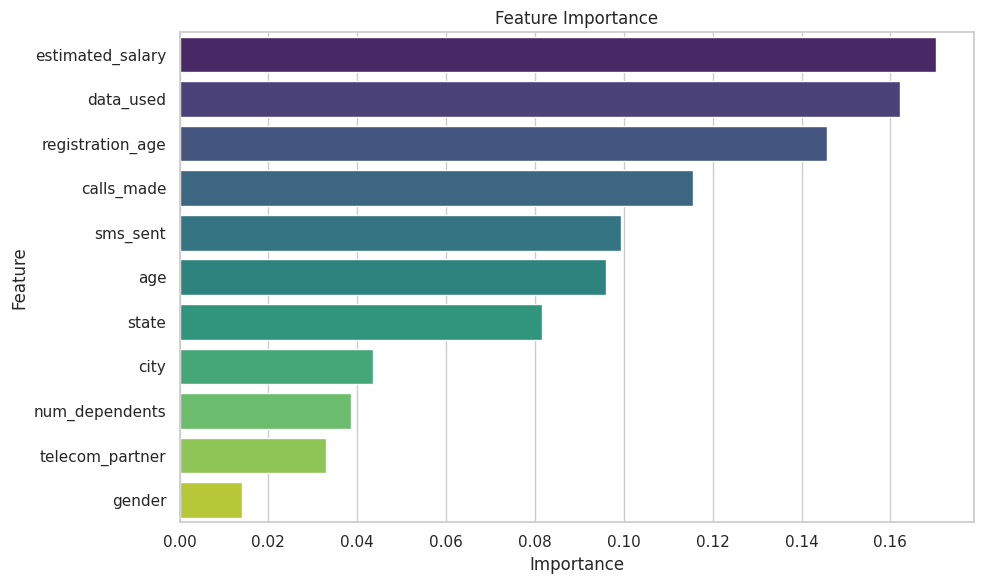

In [785]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print_model_metrics('Random Forest (100 trees, max_depth=10)', y_test, y_pred_rf)
print_feature_importance(feature_cols, rf_model.feature_importances_)

## Confusion Matrix & ROC/AUC

Evaluate all three models side by side using confusion matrices and ROC curves.

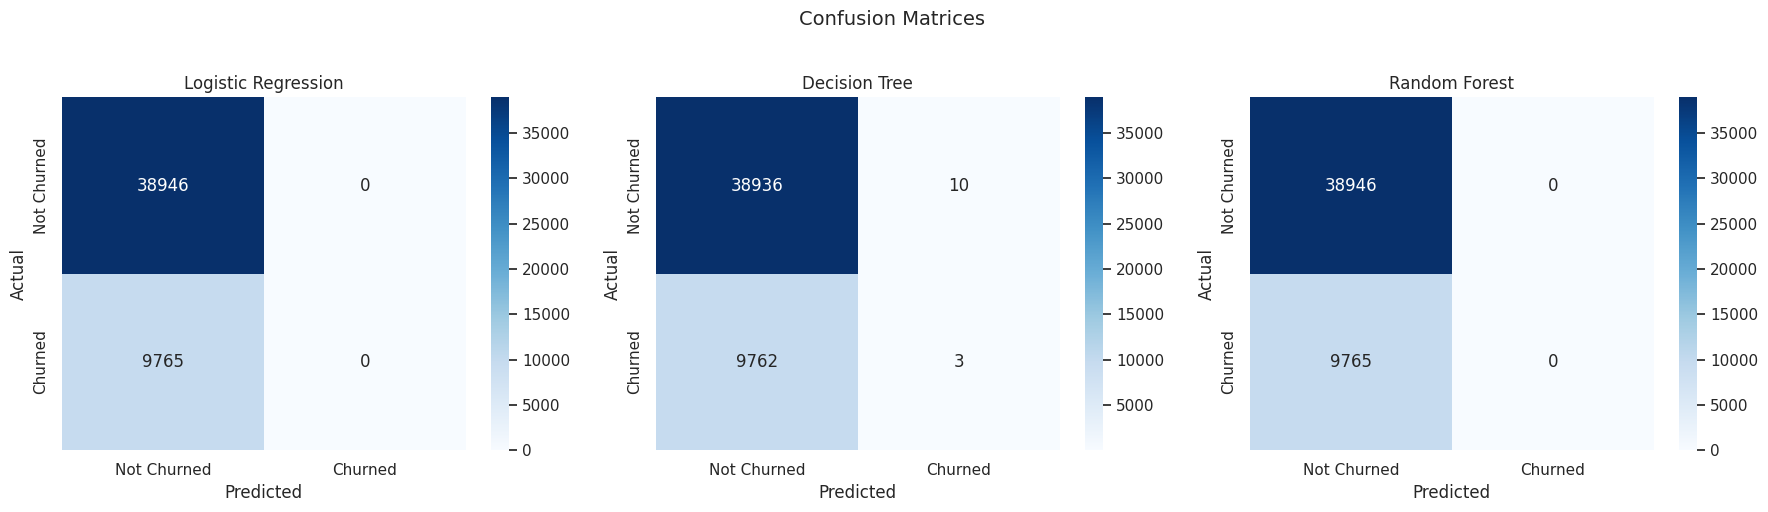

In [786]:
plot_confusion_matrices(y_test, {
    'Logistic Regression': y_pred_lr,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
})

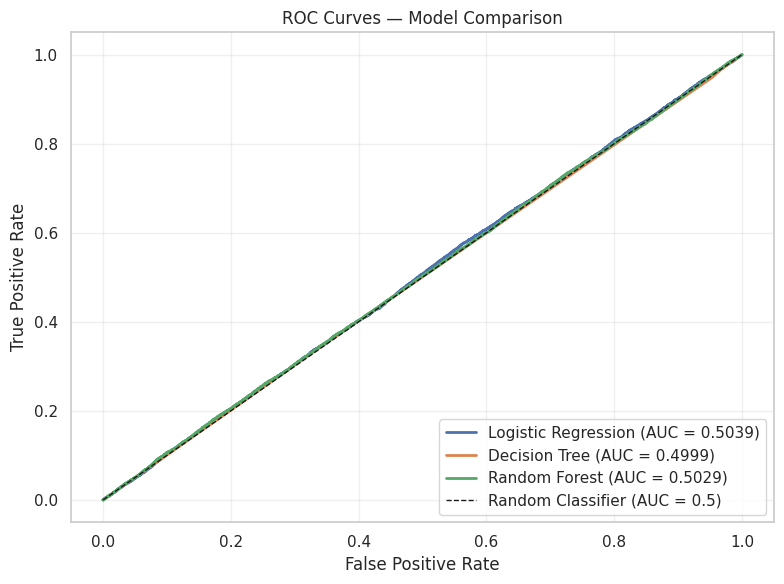


--- Model Comparison Summary ---
Model                     Accuracy     Precision    Recall       F1           AUC         
-------------------------------------------------------------------------------------
Logistic Regression       0.7995       0.0000       0.0000       0.0000       0.5039      
Decision Tree             0.7994       0.2308       0.0003       0.0006       0.4999      
Random Forest             0.7995       0.0000       0.0000       0.0000       0.5029      


In [787]:
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

plot_roc_curves(y_test, {
    'Logistic Regression': (y_pred_lr, y_prob_lr),
    'Decision Tree': (y_pred_dt, y_prob_dt),
    'Random Forest': (y_pred_rf, y_prob_rf),
})

### Key Findings

**All three models perform no better than a naive majority-class classifier:**

| Model | Accuracy | AUC | Observation |
|-------|----------|-----|-------------|
| Logistic Regression | 79.95% | 0.5039 | Predicts all as "Not Churned" — 0% recall |
| Decision Tree | 79.94% | 0.4999 | Catches only 3 out of 9,765 churned customers |
| Random Forest | 79.95% | 0.5029 | Same as logistic — predicts all as majority class |

- **AUC ≈ 0.50** for all models confirms they have **zero discriminative ability** — equivalent to random guessing
- **~80% accuracy is misleading** — it simply reflects the 80/20 class imbalance (80% not churned)
- The confusion matrices show all models predict almost exclusively "Not Churned"
- **Feature importance** (Random Forest) shows `estimated_salary`, `data_used`, and `registration_age` contribute most to tree splits, but still without predictive power for churn

**Conclusion:** The available features (demographics, geography, basic usage) are **not predictive of churn** in this dataset. The churn label appears to be nearly independent of all provided features — likely generated randomly or driven by external factors not captured in the data.